<a href="https://colab.research.google.com/github/AnchuNair/AI-Powered-Telecom-Churn-Intelligence-Platform/blob/main/Phase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**AI-Powered Telecom Churn Intelligence Platform -AI Portfolio project**

#Phase1 - Telecom Churn Prediction Fundamentals

*   Objective -
Build a basic churn prediction model.






*   ***Download the dataset from kaggle and EDA***

---






In [1]:

import kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

Using Colab cache for faster access to the 'telco-customer-churn' dataset.


In [2]:
import pandas as pd
df =pd.read_csv("/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.shape  # matrix size


(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


**Churn Distribution**


***Calculate the baseline: What percentage of your total customer base has churned?***

In [9]:
churn_counts = df['Churn'].value_counts()
churn_percentage = df['Churn'].value_counts(normalize=True) * 100

print(f"Churn Rates:\n{churn_percentage}")

Churn Rates:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


If your baseline shows 26% Churn and 74% Retained, a dumb model that guesses "No Churn" for every single user will be 74% accurate. This tells you that when you move to machine learning, you must use metrics like F1-Score or AUC-ROC instead of pure Accuracy.

***Analyze Churn Against Continuous Features***


To see how numerical variables (like monthly charges, tenure, or total data usage) distribute across churners vs. non-churners, you need to look at their probability density.

Tenure (Length of stay): Plotting this usually reveals a high concentration of churn in the first 1–6 months.

/tmp/ipykernel_4322/3466646807.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x='tenure', hue='Churn', shade=True, palette='crest')


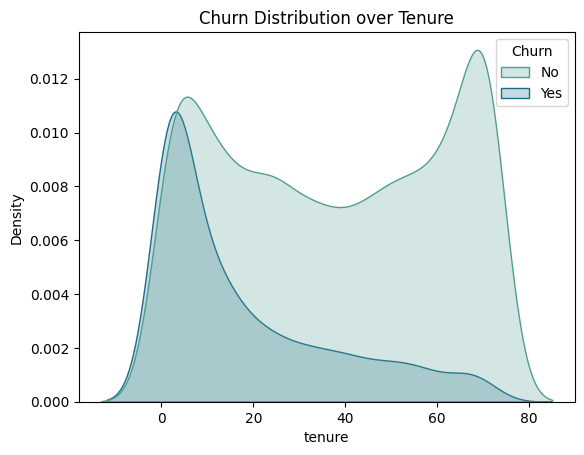

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# KDE plot for Tenure
sns.kdeplot(data=df, x='tenure', hue='Churn', shade=True, palette='crest')
plt.title('Churn Distribution over Tenure')
plt.show()

***Analyze Churn Across Categorical Features***




Demographics: Gender, Senior Citizen status, Partner (Yes/No), Dependents (Yes/No).

Account/Contract Info: Contract type (Month-to-month, One year, Two year), Paperless Billing, Payment Method (Electronic check, Mailed check, Bank transfer, Credit card).

Services Subscribed: Phone Service, Multiple Lines, Internet Service (DSL, Fiber optic, No), Online Security, Online Backup, Device Protection, Tech Support, Streaming TV, Streaming Movies.

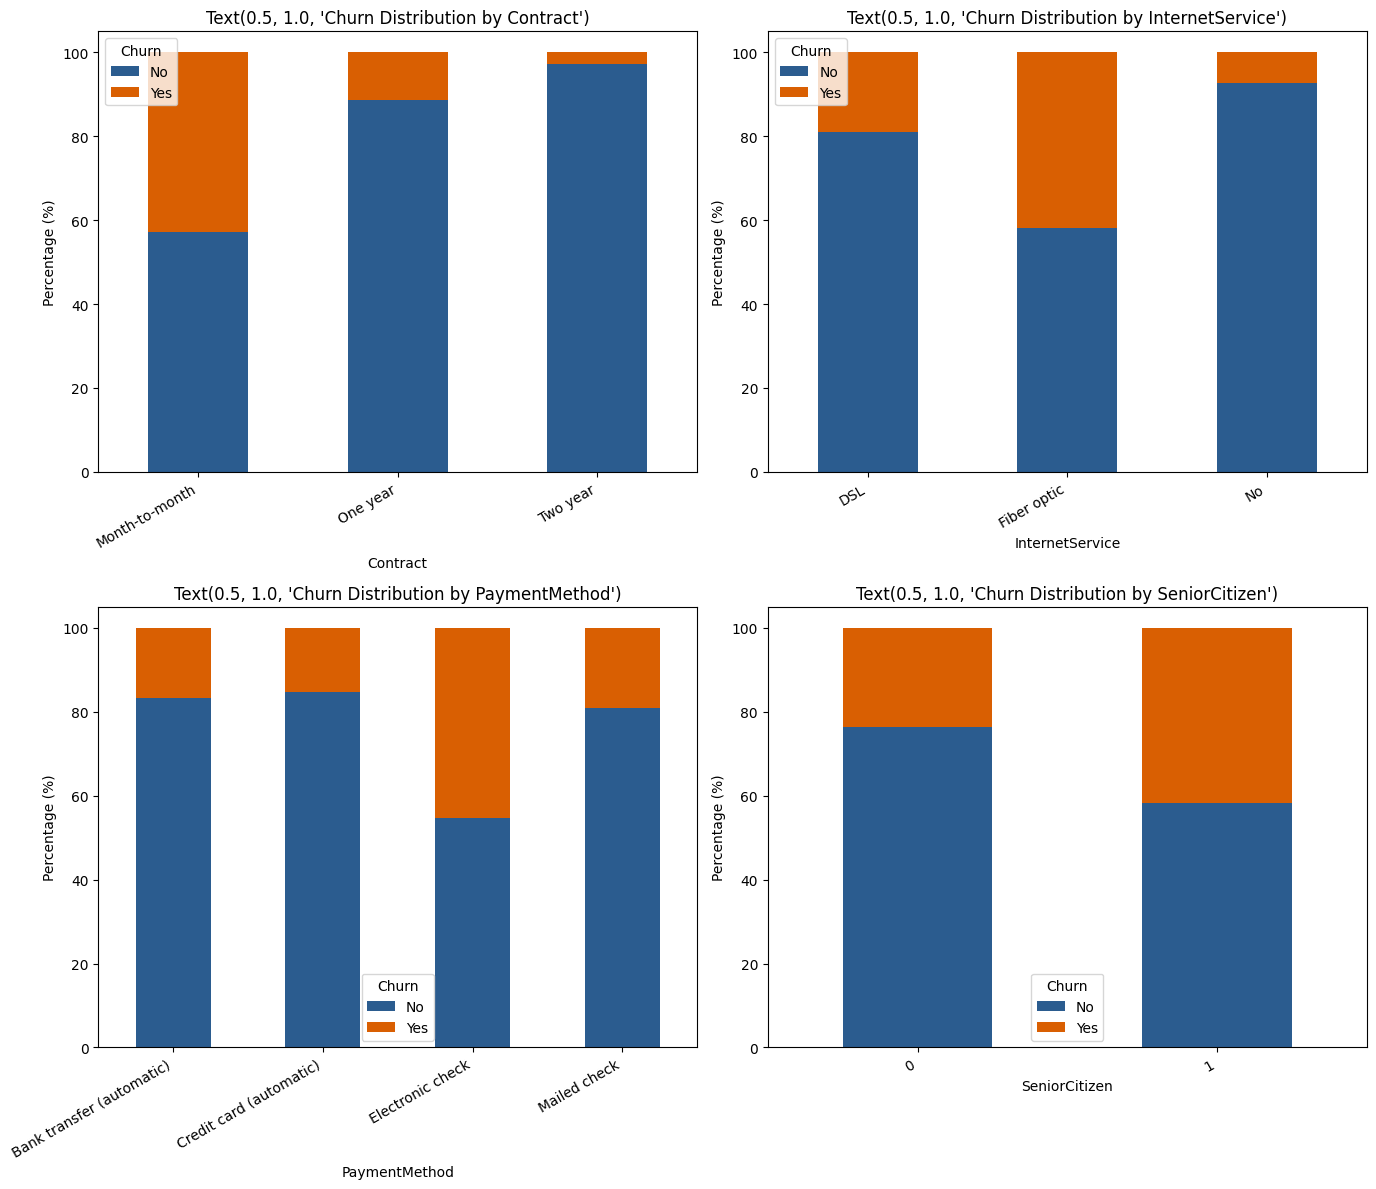

In [11]:
categorical_features = ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    # Create a normalized crosstab to show percentages instead of raw counts
    crosstab_res = pd.crosstab(df[feature], df['Churn'], normalize='index') * 100

    # Plotting
    crosstab_res.plot(kind='bar', stacked=True, ax=axes[i], color=['#2b5c8f', '#d95f02'])
    axes[i].set_title(plt.title(f'Churn Distribution by {feature}'))
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

***Statistical Feature Importance & Correlation***

 Chi-Square Test of Independence.

 Null Hypothesis ($H_0$): There is no relationship between the feature (e.g., PaymentMethod) and Churn.


 Alternative Hypothesis ($H_a$): There is a significant relationship.

In [12]:
from scipy.stats import chi2_contingency

# Test the relationship between Contract type and Churn
contingency_table = pd.crosstab(df['Contract'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2}")
print(f"p-value: {p}")

if p < 0.05:
    print("Reject the null hypothesis: The contract type significantly impacts churn distribution.")
else:
    print("Fail to reject the null hypothesis: No significant impact found.")

Chi-Square Statistic: 1184.5965720837926
p-value: 5.863038300673391e-258
Reject the null hypothesis: The contract type significantly impacts churn distribution.


In [15]:
missing_total_charges = df[df['TotalCharges'].isna() | (df['TotalCharges'] == ' ')]
print(f"Number of missing TotalCharges: {len(missing_total_charges)}")


Number of missing TotalCharges: 11
